In [1]:
# import subprocess
# import sys
# import importlib

# def install_and_import(package, alias=None):
#     try:
#         module = importlib.import_module(package)
#     except ImportError:
#         print(f"{package} not found. Installing...")
#         if package=="cv2":
#             subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python"])
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package])
#         module = importlib.import_module(package)
    
#     if alias:
#         globals()[alias] = module
#     else:
#         globals()[package] = module

# install_and_import("cv2")
# install_and_import("scipy")
# install_and_import("pylab")
# from pylab import *
# install_and_import("numpy", "np")
# install_and_import("pandas", "pd")
# install_and_import("tensorflow", "tf")
# install_and_import("matplotlib.pyplot", "plt")
# install_and_import("seaborn", "sns")
# install_and_import("PIL")
# from PIL import Image
# from tensorflow.keras.callbacks import EarlyStopping
# import random

In [2]:
import cv2
import scipy
from pylab import *
import numpy as np
import pandas as pd 
import tensorflow as tf 
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras.callbacks import EarlyStopping
import random

In [3]:
'''
Read the training and testing data set, though we only have relevence with the training data, as the test is used only for large scale testing

'''
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


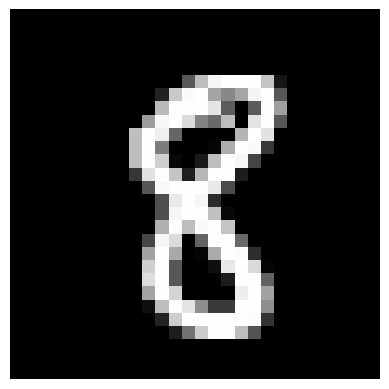

In [4]:
'''
The data is trained on 42000 different numbers of images with 784 pixels, or in other words are of 28 x 28

Here the data is handled and NaN values are filled with 0

x becomes the training data without the 'label' column
y becomes the training data with only the 'label' column

Change the value of rownum to a value > 0 and < 42000 to see what a particular value of the training data looks like. It will be stored in a file check.jpg

'''
train.shape
#(42000, 785)
train_x=train.drop('label', axis=1)
train_x = train_x.fillna(0).astype('int32')
train_y = train['label'].astype('float32')
test_x = test.fillna(0).astype('float32')

rownum=10101
#change this value to get another example from the training dataset

if rownum>-1 and rownum<42000:
  pixels=train_x.iloc[rownum].values.reshape(28, 28)
  array = np.array(pixels, dtype=np.uint8)
  img=Image.fromarray(array)
  img.save("check.jpg")
else:
  print("Row index out of bounds")

plt.imshow(img, cmap='Greys_r')
plt.axis('off')
plt.show()

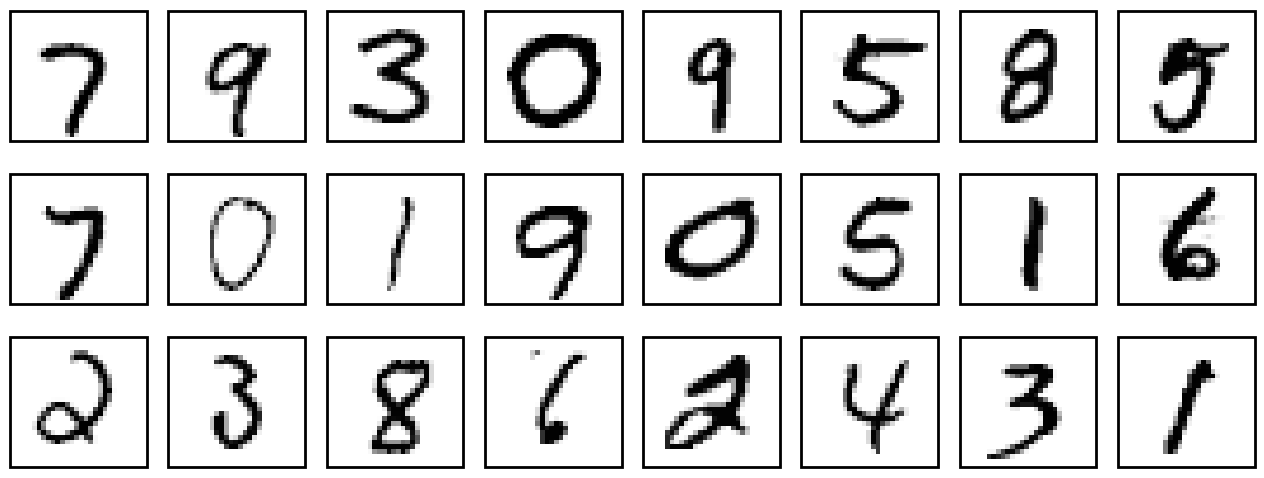

In [5]:
'''
Rerun as required to view samples of the data

'''
random_indices = np.random.choice(range(len(train_x)), size=24, replace=False)
_, axes = plt.subplots(3, 8, figsize=(16, 6))
for i,ax in enumerate(axes.ravel()):
    ax.imshow(train.iloc[random_indices[i]][1:].values.reshape(28, 28), cmap='Greys')
    ax.axis('off')
    
    autoAxis = ax.axis()
    rec = Rectangle((autoAxis[0]-0.7,autoAxis[2]-0.2),(autoAxis[1]-autoAxis[0])+1,(autoAxis[3]-autoAxis[2])+0.4,fill=False,lw=2, color="black")
    rec = ax.add_patch(rec)
    rec.set_clip_on(False)
plt.show()

In [6]:
'''
Neural networks perform better when all values are in the similar small range, hence, all values are divided by 255
The linear storage of 42000 data is then converted to 42000 instances of two dimensional pixel information for better processing by the network

'''

train_x = train_x.values.reshape(-1, 28, 28, 1)
train_x = train_x / 255.0
test_x = test_x.values.reshape(-1, 28, 28, 1)
test_x = test_x / 255.0


In [7]:
'''
The target values stored in y can be of 10 different values, and are categorical based eventhough they are integers
Here the vales are one-hot encoded to 10 different columns for each value

'''
train_y = tf.keras.utils.to_categorical(train_y,10)
train_y.shape

(42000, 10)

In [8]:
'''
This is the model of the Neural Network that is going to be trained for Number identification

'''
model = tf.keras.models.Sequential([

    #These layers take the 28x28 image and read it in 3x3 sections to analyse features reducing its size gradually, and then it is shrunk to half
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    #The same as before happens here, except the size is kept the same, but again in the end, it is halved
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='Same'),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='Same'),
    tf.keras.layers.MaxPooling2D(pool_size = (2,2), strides = (2,2)),

    #The previous layers are repeated again allowing the model to comprehend more complex features, and make identifications regardless of the spatial position
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='Same'),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='Same'),
    tf.keras.layers.MaxPooling2D(pool_size = (2,2), strides = (2,2)),

    #This layer flattens the 2D image into a linear form for the next layers
    tf.keras.layers.Flatten(),

    #These layers are the ones responsible for analysing patterns and making predictions from the flattened layer
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
    #The final output is of size 10 for each of the possible digits in the classification which is keyworded by the tag 'softmax'
])
model.summary()

c:\Users\Hrithik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,906 (737.91 KB)

 Trainable params: 188,906 (737.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
'''
The model is going to be trained with accuracy as the main metric of efficiency, and will early stop if the validation accuracy does not improve beyond 00.01%
It was observed that 10 epochs is the average amount and more are not needed

'''
early_stopping = EarlyStopping(
    min_delta=0.0001,
    patience=5, 
    monitor='val_accuracy',
    restore_best_weights=True,
)
model.compile(
    optimizer = 'Adam',
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)
history=model.fit(
    train_x,train_y,
    validation_split=0.2,
    callbacks=[early_stopping],
    batch_size=42,
    epochs=20
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8395 - loss: 0.4713 - val_accuracy: 0.9806 - val_loss: 0.0632
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9789 - loss: 0.0691 - val_accuracy: 0.9825 - val_loss: 0.0563
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9876 - loss: 0.0445 - val_accuracy: 0.9842 - val_loss: 0.0512
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 0.9823 - val_loss: 0.0553
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9894 - loss: 0.0329 - val_accuracy: 0.9874 - val_loss: 0.0412
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9870 - val_loss: 0.0437
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9941 - loss: 0.0194 - val_accuracy: 0.9886 - val_loss: 0.0398
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9944 - loss: 0.0178 - v

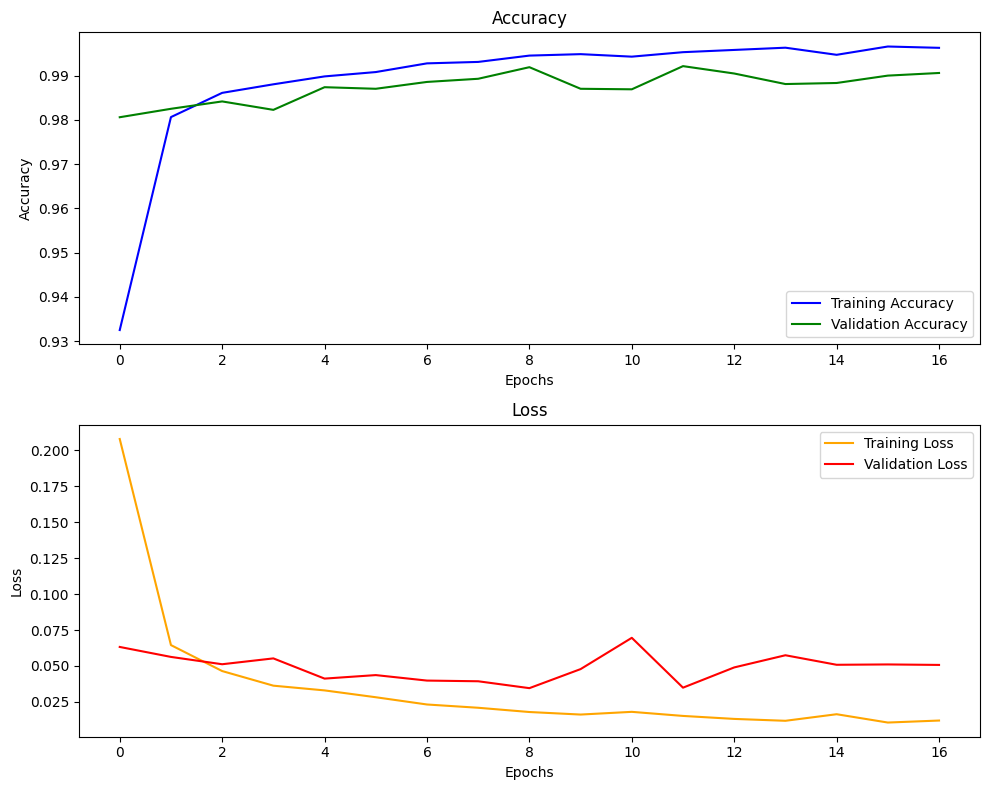

In [10]:
'''
Just to simply plot the change of loss and accuracy over the training period

'''
history_df = pd.DataFrame(history.history)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(history_df['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history_df['val_accuracy'], label='Validation Accuracy', color='green')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_df['loss'], label='Training Loss', color='orange')
ax2.plot(history_df['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()




plt.tight_layout()
plt.show()

In [11]:
'''
This creates the predictions for the given test information

'''
result = model.predict(test_x)
result = np.argmax(result,axis = 1)
result = pd.Series(result,name='Label')
result

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


0        2
1        0
2        9
3        0
4        3
        ..
27995    9
27996    7
27997    3
27998    9
27999    2
Name: Label, Length: 28000, dtype: int64

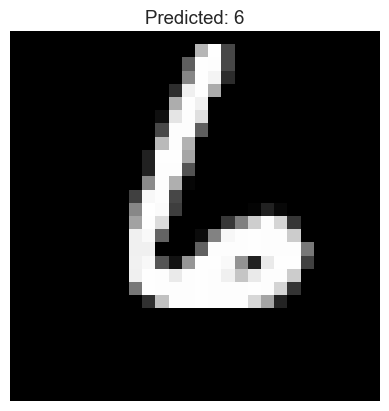

In [36]:
'''
This is jut to check the results of the test
(Rerun the cell multiple times)
'''
index=random.randint(0, 27999)
#this randomly selects a value from the test data for verification, or run the following
#index = 3

pixinfo=test.iloc[index][:].values.reshape(28, 28)
array = np.array(pixinfo, dtype=np.uint8)
img=Image.fromarray(array)


plt.imshow(img, cmap='Greys_r')
plt.axis('off')
plt.title(f'Predicted: {result[index]}')
plt.show()

In [13]:
'''
Here we see how many of the predictions of the Network are incorrect from the training data itself as we dont have the answers for the testing

'''
tr_res=model.predict(train_x)
tr_res = np.argmax(tr_res,axis = 1)
tr_res = pd.Series(tr_res,name='Label')
wrong_predictions = np.where(tr_res != train['label'])[0]
right_predictions = np.where(tr_res == train['label'])[0]
wrong_predictions.shape
print(f"{wrong_predictions.shape[0]} Incorrect out of 42000")


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
164 Incorrect out of 42000


[Text(0.5, 20.71666666666666, 'Prediction'),
 Text(47.91666666666667, 0.5, 'Actual')]

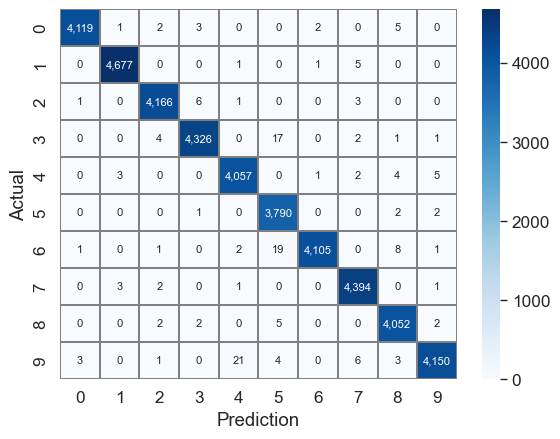

In [14]:
df_confusion = pd.crosstab(train['label'], tr_res)
sns.set_theme(font_scale=1.4, context='paper')
hm=sns.heatmap(df_confusion, annot=True, annot_kws={"size": 8}, cmap='Blues', fmt=',d', linewidths=0.1, linecolor="grey")
hm.set(xlabel='Prediction', ylabel='Actual')

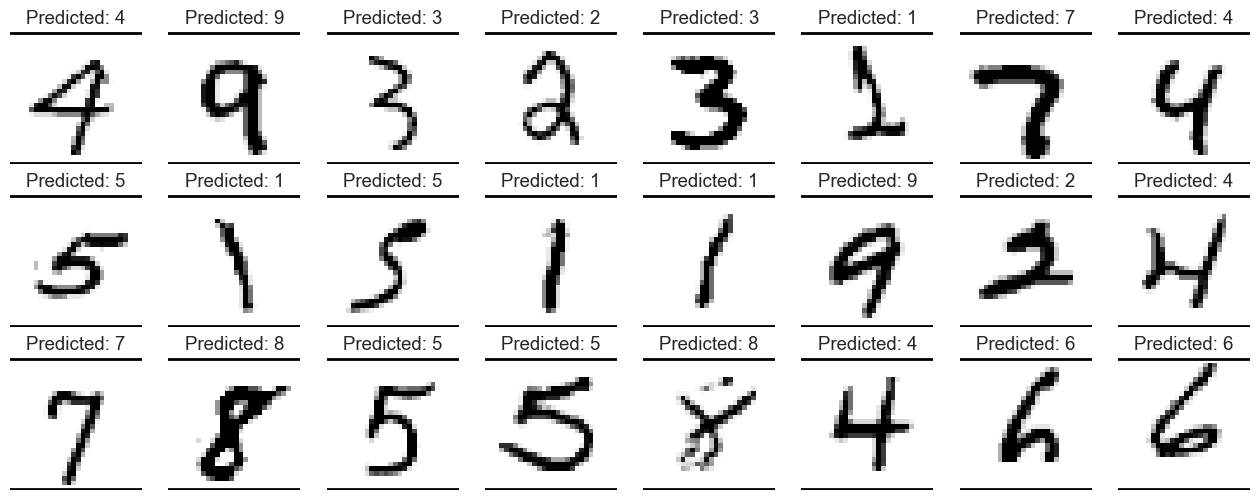

In [15]:
'''
Here we can view the correct values

'''
np.random.shuffle(right_predictions)
_, axes = plt.subplots(3, 8, figsize=(16, 6))
for i,ax in enumerate(axes.ravel()):
    ax.imshow(train.iloc[right_predictions[i]][1:].values.reshape(28, 28), cmap='Greys')
    ax.axis('off')
    ax.set_title(f'Predicted: {tr_res[right_predictions[i]]}')
    autoAxis = ax.axis()
    rec = Rectangle((autoAxis[0]-0.7,autoAxis[2]-0.2),(autoAxis[1]-autoAxis[0])+1,(autoAxis[3]-autoAxis[2])+0.4,fill=False,lw=2, color="black")
    rec = ax.add_patch(rec)
    rec.set_clip_on(True)

plt.show()

C:\Users\Hrithik\AppData\Local\Temp\ipykernel_41680\2393703484.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_title(f'Actual: {train.iloc[wrong_predictions[i]][0]},\n Predicted: {tr_res[wrong_predictions[i]]}')


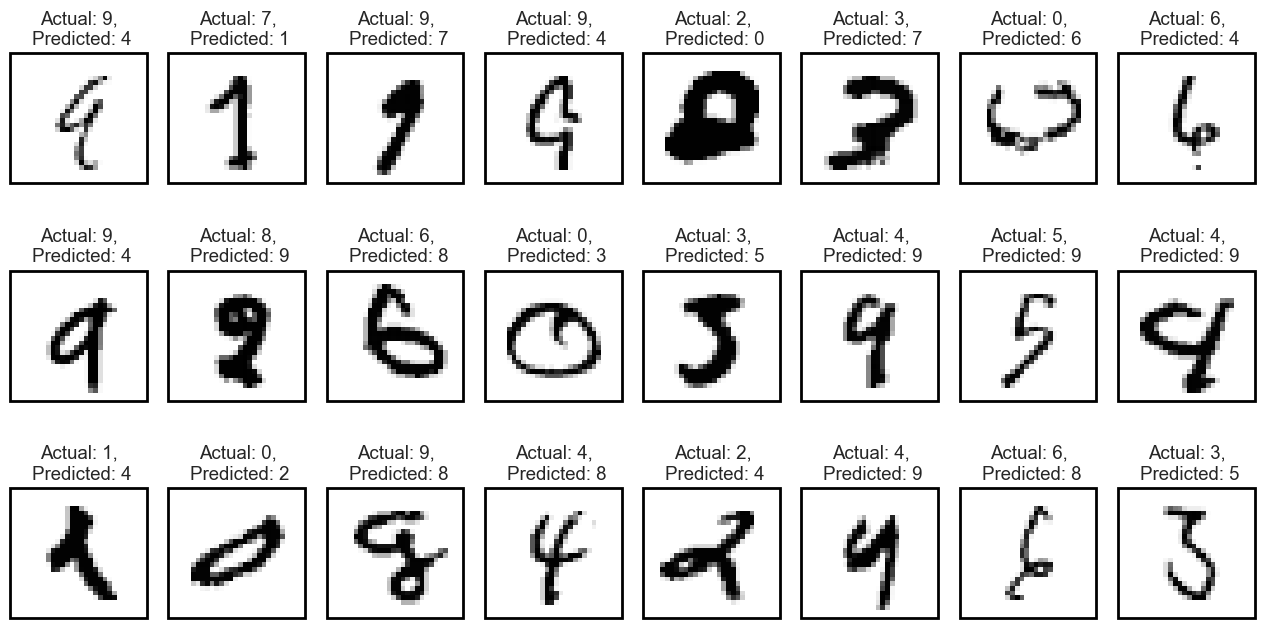

In [16]:
'''
Here we can view the incorrect values

'''
np.random.shuffle(wrong_predictions)
_, axes = plt.subplots(3, 8, figsize=(16, 8))
for i,ax in enumerate(axes.ravel()):
    ax.imshow(train.iloc[wrong_predictions[i]][1:].values.reshape(28, 28), cmap='Greys')
    ax.axis('off')
    ax.set_title(f'Actual: {train.iloc[wrong_predictions[i]][0]},\n Predicted: {tr_res[wrong_predictions[i]]}')
    autoAxis = ax.axis()
    rec = Rectangle((autoAxis[0]-0.7,autoAxis[2]-0.2),(autoAxis[1]-autoAxis[0])+1,(autoAxis[3]-autoAxis[2])+0.4,fill=False,lw=2, color="black")
    rec = ax.add_patch(rec)
    rec.set_clip_on(False)

plt.show()

# THE MODEL IS NOW TRAINED
### The cells below are now to deal with user input

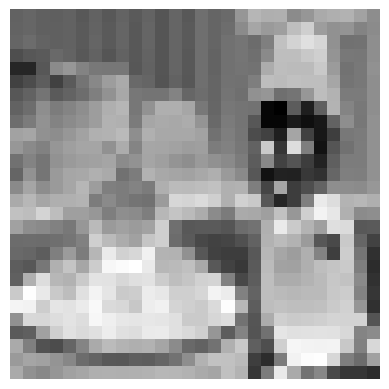

In [23]:
'''
Here the user generated image is taken, downgraded and resized to the required pixel size of 28 x 28
The image is also then inverted and stored
The pixel information is then extracted and stored in a list and converted to a dataframe and then reshaped to match the format required by the model

'''

im=Image.open("input.jpg") #Image should be Black text on white background
im = im.convert('L')
rim=im.resize((28,28))
rim = Image.eval(rim, lambda x: 255 - x)
rim.save("target.jpg")
val=list(rim.getdata())

v=pd.DataFrame(val).T
v = v.values.reshape(-1, 28, 28, 1)
v = v / 255.0

plt.imshow(rim, cmap='Greys_r')
plt.axis('off')
plt.show()

In [24]:
'''
Here the values are sent for prediction and printed

'''
answer = model.predict(v)
answer = np.argmax(answer,axis = 1)
print(answer[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
6
